## Cell 1 — Dependencies & reproducibility

In [4]:
import subprocess, sys, importlib, os, random

for pkg in ["torch","numpy","pandas","scikit-learn","matplotlib","seaborn","optuna"]:
    try:
        importlib.import_module(pkg.replace("-","_"))
        print(f"  ok  {pkg}")
    except ImportError:
        subprocess.check_call([sys.executable,"-m","pip","install",pkg,"-q"])
        print(f"  installed {pkg}")

import torch
import numpy as np

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ["PYTHONHASHSEED"]       = str(seed)
    print(f"All seeds fixed to {seed}")

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

  ok  torch
  ok  numpy
  ok  pandas
  installed scikit-learn
  ok  matplotlib
  ok  seaborn
  installed optuna
All seeds fixed to 42
Device : cuda
GPU    : Tesla T4


## Cell 2 — Upload data files

In [5]:
import os, zipfile
from google.colab import files

os.makedirs("data",    exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Upload twitter_training.csv  AND  twitter_validation.csv")
uploaded = files.upload()

for name, content in uploaded.items():
    dest = f"data/{name}"
    with open(dest, "wb") as f:
        f.write(content)
    if name.endswith(".zip"):
        with zipfile.ZipFile(dest) as z:
            z.extractall("data/")
        os.remove(dest)
        print(f"  Extracted {name}")
    else:
        print(f"  Saved    {name}")

print("\nFiles in data/:")
for fname in sorted(os.listdir("data")):
    kb = os.path.getsize(f"data/{fname}") / 1024
    print(f"  {fname}  ({kb:,.0f} KB)")

Upload twitter_training.csv  AND  twitter_validation.csv


Saving twitter_validation.csv to twitter_validation.csv
Saving twitter_training.csv.zip to twitter_training.csv.zip
  Saved    twitter_validation.csv
  Extracted twitter_training.csv.zip

Files in data/:
  twitter_training.csv  (10,083 KB)
  twitter_validation.csv  (160 KB)


## Cell 3 — Preprocessing utilities

In [6]:
import re
import json as _json
import pandas as pd
import numpy as np
from collections import Counter
from typing import List, Dict
from torch.utils.data import Dataset
import torch

LABEL_MAP   = {"Positive":0, "Negative":1, "Neutral":2, "Irrelevant":3}
ID2LABEL    = {v: k for k, v in LABEL_MAP.items()}
PAD_IDX, UNK_IDX = 0, 1
CLASS_NAMES = ["Positive","Negative","Neutral","Irrelevant"]

def clean_tweet(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = text.lower()
    text = re.sub(r"#(\w+)", r"\1", text)
    contrs = {
        r"won't":"will not", r"can't":"cannot", r"n't":" not",
        r"'re":" are", r"'s":" is", r"'d":" would",
        r"'ll":" will", r"'ve":" have", r"'m":" am",
    }
    for pat, rep in contrs.items():
        text = re.sub(pat, rep, text)
    text = text.encode("ascii","ignore").decode()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", "", text)
    return " ".join(text.split())

def load_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, header=None,
                     names=["id","topic","sentiment","text"],
                     encoding="utf-8", on_bad_lines="skip", engine="python")
    df = df[df["sentiment"].isin(LABEL_MAP)].copy()
    df["text"]  = df["text"].astype(str).str.strip()
    df = df[df["text"] != ""].copy()
    df["label"] = df["sentiment"].map(LABEL_MAP)
    print(f"Loaded {len(df):,} rows  |  {path}")
    print(df["sentiment"].value_counts().to_string(), "\n")
    return df[["text","label"]].reset_index(drop=True)

class Vocabulary:
    def __init__(self, max_vocab=20_000, min_freq=2):
        self.max_vocab  = max_vocab
        self.min_freq   = min_freq
        self.word2idx: Dict[str,int] = {}
        self.vocab_size = 0

    def build(self, texts: List[str]):
        counter = Counter(w for t in texts for w in t.split())
        tokens  = [w for w,c in counter.items() if c >= self.min_freq]
        tokens  = sorted(tokens, key=lambda w: (-counter[w], w))[:self.max_vocab-2]
        self.word2idx = {"<PAD>":0, "<UNK>":1}
        self.word2idx.update({w: i+2 for i,w in enumerate(tokens)})
        self.vocab_size = len(self.word2idx)
        print(f"Vocabulary: {self.vocab_size:,} tokens")

    def encode(self, text: str) -> List[int]:
        return [self.word2idx.get(w, UNK_IDX) for w in text.split()]

    def save(self, path: str):
        payload = {"max_vocab":self.max_vocab, "min_freq":self.min_freq,
                   "vocab_size":self.vocab_size, "word2idx":self.word2idx}
        with open(path, "w", encoding="utf-8") as f:
            _json.dump(payload, f, ensure_ascii=False)
        print(f"Vocab saved to {path}  ({os.path.getsize(path)/1024:.0f} KB)")

    @staticmethod
    def load(path: str) -> "Vocabulary":
        with open(path, "r", encoding="utf-8") as f:
            payload = _json.load(f)
        v = Vocabulary(payload["max_vocab"], payload["min_freq"])
        v.word2idx   = payload["word2idx"]
        v.vocab_size = payload["vocab_size"]
        print(f"Vocab loaded: {v.vocab_size:,} tokens")
        return v

class TwitterDataset(Dataset):
    def __init__(self, df: pd.DataFrame, vocab: Vocabulary, max_len=100):
        self.vocab   = vocab
        self.max_len = max_len
        self.texts   = [clean_tweet(t) for t in df["text"].tolist()]
        self.labels  = df["label"].tolist()

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.vocab.encode(self.texts[idx])[:self.max_len]
        if len(enc) == 0:
            enc = [UNK_IDX]
        enc += [PAD_IDX] * (self.max_len - len(enc))
        return (torch.tensor(enc, dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.long))

print("Preprocessing utilities ready")

Preprocessing utilities ready


## Cell 4 — Load data & three-way split

Loaded 74,510 rows  |  data/twitter_training.csv
sentiment
Negative      22496
Positive      20796
Neutral       18261
Irrelevant    12957 

Loaded 1,000 rows  |  data/twitter_validation.csv
sentiment
Neutral       285
Positive      277
Negative      266
Irrelevant    172 

Train : 67,059
Val   : 1,000   <- early-stopping only, NOT for final reporting
Test  : 7,451   <- held-out, touched only once at the very end


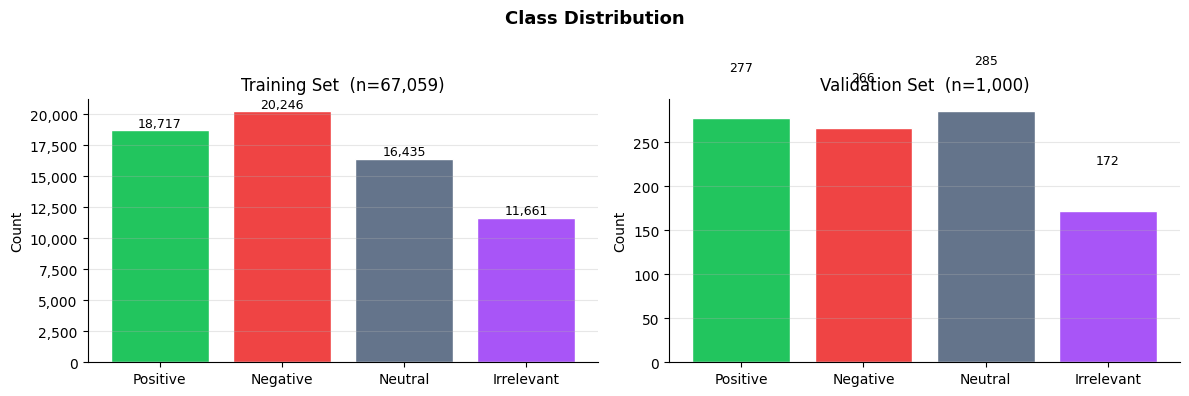

Token-length percentiles:
  p90 = 40 tokens
  p95 = 47 tokens
  p99 = 56 tokens
Tweets covered by max_len=100: 100.0%


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split

data_files = os.listdir("data")
train_path = next((f"data/{f}" for f in data_files
                   if "train" in f.lower() and f.endswith(".csv")), None)
val_path   = next((f"data/{f}" for f in data_files
                   if "val"   in f.lower() and f.endswith(".csv")), None)

assert train_path, "Training CSV not found in data/"
assert val_path,   "Validation CSV not found in data/"

full_train_df = load_csv(train_path)
val_df        = load_csv(val_path)

# Carve 10% off training as a held-out test set (stratified)
train_df, test_df = train_test_split(
    full_train_df, test_size=0.10,
    random_state=SEED, stratify=full_train_df["label"])
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df):,}")
print(f"Val   : {len(val_df):,}   <- early-stopping only, NOT for final reporting")
print(f"Test  : {len(test_df):,}   <- held-out, touched only once at the very end")

COLORS = ["#22c55e","#ef4444","#64748b","#a855f7"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Class Distribution", fontsize=13, fontweight="bold")
for ax, df, title in [(axes[0], train_df, "Training Set"),
                      (axes[1], val_df,   "Validation Set")]:
    counts = [int((df["label"]==i).sum()) for i in range(4)]
    bars = ax.bar(CLASS_NAMES, counts, color=COLORS, edgecolor="white")
    ax.set_title(f"{title}  (n={len(df):,})")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f"{count:,}", ha="center", va="bottom", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

train_df["n_tokens"] = train_df["text"].apply(lambda t: len(clean_tweet(t).split()))
pcts = train_df["n_tokens"].quantile([0.90, 0.95, 0.99]).astype(int)
print("Token-length percentiles:")
for q, v in pcts.items():
    print(f"  p{int(q*100):02d} = {v} tokens")
pct = (train_df["n_tokens"] <= 100).mean() * 100
print(f"Tweets covered by max_len=100: {pct:.1f}%")

## Cell 5 — TF-IDF + Logistic Regression baseline

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model            import LogisticRegression
from sklearn.pipeline                import Pipeline
from sklearn.metrics                 import classification_report, f1_score, accuracy_score
import time

print("=" * 60)
print("BASELINE : TF-IDF + Logistic Regression")
print("=" * 60)

X_train_raw = [clean_tweet(t) for t in train_df["text"]]
X_val_raw   = [clean_tweet(t) for t in val_df["text"]]
y_train     = train_df["label"].tolist()
y_val       = val_df["label"].tolist()

baseline_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=50_000,
                               sublinear_tf=True, min_df=2)),
    ("clf",   LogisticRegression(C=1.0, max_iter=1_000, class_weight="balanced",
                                  solver="lbfgs", multi_class="multinomial",
                                  random_state=SEED, n_jobs=-1)),
])

t0 = time.time()
baseline_pipe.fit(X_train_raw, y_train)
val_preds_baseline = baseline_pipe.predict(X_val_raw)
elapsed = time.time() - t0

baseline_macro_f1 = f1_score(y_val, val_preds_baseline, average="macro")
baseline_acc      = accuracy_score(y_val, val_preds_baseline)

print(f"Train + eval time : {elapsed:.1f}s")
print(f"Val accuracy      : {baseline_acc:.4f}")
print(f"Val macro F1      : {baseline_macro_f1:.4f}\n")
print(classification_report(y_val, val_preds_baseline,
                             target_names=CLASS_NAMES, digits=4))

BASELINE_RESULTS = {"model":"TF-IDF + LogReg (baseline)",
                    "val_acc":round(baseline_acc,4),
                    "macro_f1":round(baseline_macro_f1,4)}
print("Baseline stored. BiLSTM must beat this to justify its compute cost.")

BASELINE : TF-IDF + Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Train + eval time : 19.0s
Val accuracy      : 0.9550
Val macro F1      : 0.9536

              precision    recall  f1-score   support

    Positive     0.9487    0.9350    0.9418       277
    Negative     0.9665    0.9774    0.9720       266
     Neutral     0.9647    0.9579    0.9613       285
  Irrelevant     0.9314    0.9477    0.9395       172

    accuracy                         0.9550      1000
   macro avg     0.9528    0.9545    0.9536      1000
weighted avg     0.9550    0.9550    0.9550      1000

Baseline stored. BiLSTM must beat this to justify its compute cost.


## Cell 6 — Build vocabulary & datasets

In [9]:
MAX_VOCAB = 20_000
MIN_FREQ  = 2
MAX_LEN   = 100

train_texts_clean = [clean_tweet(t) for t in train_df["text"].tolist()]
vocab = Vocabulary(max_vocab=MAX_VOCAB, min_freq=MIN_FREQ)
vocab.build(train_texts_clean)
vocab.save("outputs/vocab.json")

train_dataset = TwitterDataset(train_df, vocab, MAX_LEN)
val_dataset   = TwitterDataset(val_df,   vocab, MAX_LEN)
test_dataset  = TwitterDataset(test_df,  vocab, MAX_LEN)

print(f"Train samples : {len(train_dataset):,}")
print(f"Val   samples : {len(val_dataset):,}")
print(f"Test  samples : {len(test_dataset):,}")

tok, lbl = train_dataset[0]
print(f"Sample shape  : {tok.shape}")
print(f"Sample label  : {lbl.item()} ({ID2LABEL[lbl.item()]})")

Vocabulary: 20,000 tokens
Vocab saved to outputs/vocab.json  (340 KB)
Train samples : 67,059
Val   samples : 1,000
Test  samples : 7,451
Sample shape  : torch.Size([100])
Sample label  : 1 (Negative)


In [10]:
import json

# Re-save vocab as proper JSON
payload = {
    "max_vocab"  : vocab.max_vocab,
    "min_freq"   : vocab.min_freq,
    "vocab_size" : vocab.vocab_size,
    "word2idx"   : vocab.word2idx,
}
with open("outputs/vocab.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False)

print(f"Saved outputs/vocab.json  ({os.path.getsize('outputs/vocab.json')/1024:.0f} KB)")

# Verify it's valid JSON
with open("outputs/vocab.json", "r", encoding="utf-8") as f:
    test = json.load(f)
print(f"Verified: {test['vocab_size']:,} tokens loaded cleanly")

Saved outputs/vocab.json  (340 KB)
Verified: 20,000 tokens loaded cleanly


## Cell 7 — Model architecture

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out, mask):
        scores  = self.attn(lstm_out).squeeze(-1)
        scores  = scores.masked_fill(mask == 0, -1e9)
        weights = F.softmax(scores, dim=-1)
        return (weights.unsqueeze(-1) * lstm_out).sum(dim=1)

class LSTMSentimentClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 num_layers=2, num_classes=4, dropout=0.4, pad_idx=0):
        super().__init__()
        self.pad_idx       = pad_idx
        self.embedding     = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.embed_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0)
        lstm_out_dim    = hidden_dim * 2
        self.attention  = AttentionPooling(lstm_out_dim)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_dim, num_classes))
        self._init_weights()

    def _init_weights(self):
        for name, p in self.lstm.named_parameters():
            if   "weight_ih" in name: nn.init.xavier_uniform_(p)
            elif "weight_hh" in name: nn.init.orthogonal_(p)
            elif "bias"      in name:
                p.data.fill_(0)
                n = p.size(0)
                p.data[n//4:n//2].fill_(1)
        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, token_ids):
        mask     = (token_ids != self.pad_idx)
        embedded = self.embed_dropout(self.embedding(token_ids))
        lengths  = mask.sum(dim=1).cpu().clamp(min=1)
        packed   = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths, batch_first=True, enforce_sorted=False)
        lstm_out, _ = self.lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(
            lstm_out, batch_first=True, total_length=token_ids.size(1))
        return self.classifier(self.attention(lstm_out, mask))

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

model = LSTMSentimentClassifier(vocab_size=vocab.vocab_size).to(device)
print(model)
print(f"\nTrainable parameters: {model.count_parameters():,}")

LSTMSentimentClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (embed_dropout): Dropout(p=0.4, inplace=False)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (attention): AttentionPooling(
    (attn): Linear(in_features=512, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(in_features=512, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)

Trainable parameters: 5,060,357


## Cell 8 — GloVe Twitter embeddings (Google Drive)

**One-time setup:** Upload `glove.twitter.27B.100d.txt` to your Google Drive,
then update `GLOVE_PATH` below to match its location.
If you want to skip GloVe, just skip this cell entirely.

In [8]:
import os, torch
from google.colab import drive

GLOVE_FILE = "glove.twitter.27B.100d.txt"
GLOVE_DIM  = 100

drive.mount("/content/drive")

# UPDATE THIS to match where you saved the file in your Drive
GLOVE_PATH = "/content/drive/MyDrive/GloVe/glove.twitter.27B.100d.txt"

if not os.path.exists(GLOVE_PATH):
    # List your Drive root to help find the file
    print("File not found. Contents of MyDrive:")
    for f in sorted(os.listdir("/content/drive/MyDrive"))[:20]:
        print(f"  {f}")
    raise FileNotFoundError(
        f"Update GLOVE_PATH to point to your glove.twitter.27B.100d.txt")

print(f"Found: {GLOVE_PATH}  ({os.path.getsize(GLOVE_PATH)/1024/1024:.0f} MB)")

def load_glove_matrix(vocab, glove_path, embed_dim):
    matrix = torch.randn(vocab.vocab_size, embed_dim) * 0.01
    matrix[PAD_IDX] = 0.0
    hits = 0
    with open(glove_path, encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word  = parts[0]
            if word in vocab.word2idx:
                vocab.word2idx
                matrix[vocab.word2idx[word]] = torch.tensor([float(x) for x in parts[1:]])
                hits += 1
    coverage = hits / max(vocab.vocab_size - 2, 1) * 100
    print(f"GloVe coverage : {hits:,} / {vocab.vocab_size-2:,} tokens ({coverage:.1f}%)")
    return matrix

glove_matrix = load_glove_matrix(vocab, GLOVE_PATH, GLOVE_DIM)

if model.embedding.weight.shape[1] != GLOVE_DIM:
    print(f"WARNING: model embed_dim={model.embedding.weight.shape[1]} != {GLOVE_DIM}. "
          "Re-instantiate model with embed_dim=100.")
else:
    with torch.no_grad():
        model.embedding.weight.copy_(glove_matrix.to(device))
    print("GloVe weights loaded into model.embedding")

FREEZE_EMBED_EPOCHS = 3

def set_embed_grad(model, requires_grad):
    model.embedding.weight.requires_grad_(requires_grad)

set_embed_grad(model, requires_grad=False)
print(f"Embedding frozen for first {FREEZE_EMBED_EPOCHS} epochs.")
print(f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable params")

Mounted at /content/drive
Found: /content/drive/MyDrive/GloVe/glove.twitter.27B.100d.txt  (974 MB)
GloVe coverage : 15,444 / 19,998 tokens (77.2%)
Embedding frozen for first 3 epochs.
2,500,357 trainable params


## Cell 9 — Train the model

In [9]:
import time
import json
from collections import Counter, defaultdict
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn as nn
import numpy as np

# Use Optuna best values if available, else defaults
BATCH_SIZE   = globals().get("BATCH_SIZE", 128)
LR           = globals().get("LR",         3e-4)
EPOCHS       = 20
WEIGHT_DECAY = 1e-2
PATIENCE     = 5
CLIP_GRAD    = 1.0

label_counts  = Counter(train_dataset.labels)
total_samples = len(train_dataset)
sample_w      = [total_samples / max(label_counts[l], 1) for l in train_dataset.labels]
sampler       = WeightedRandomSampler(sample_w, num_samples=total_samples, replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE*2,
                          shuffle=False,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE*2,
                          shuffle=False,  num_workers=2)

class_weights = torch.tensor(
    [total_samples / (4 * max(label_counts[c], 1)) for c in range(4)],
    dtype=torch.float, device=device)
print(f"Class weights: { {ID2LABEL[i]: round(class_weights[i].item(),3) for i in range(4)} }")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR/20)

def compute_metrics(preds, labels, n=4):
    tp = defaultdict(int); fp = defaultdict(int); fn = defaultdict(int)
    for p, l in zip(preds, labels):
        if p == l: tp[l] += 1
        else:      fp[p] += 1; fn[l] += 1
    f1s = []
    for c in range(n):
        pr = tp[c] / (tp[c] + fp[c] + 1e-8)
        rc = tp[c] / (tp[c] + fn[c] + 1e-8)
        f1s.append(2*pr*rc / (pr+rc+1e-8))
    acc = sum(p==l for p,l in zip(preds,labels)) / max(len(labels),1)
    return {"accuracy":round(acc,4),
            "macro_f1":round(float(np.mean(f1s)),4),
            "per_class_f1":{ID2LABEL[c]:round(f1s[c],4) for c in range(n)}}

history = {k:[] for k in ["train_loss","val_loss","train_f1","val_f1","train_acc","val_acc"]}
best_val_f1, patience_ctr, best_metrics = -1.0, 0, {}

hdr = f"{'Ep':>4} {'TrLoss':>8} {'VaLoss':>8} {'TrF1':>7} {'VaF1':>7} {'VaAcc':>7} {'Time':>6}"
print(hdr); print("-"*len(hdr))

for epoch in range(1, EPOCHS+1):
    if "FREEZE_EMBED_EPOCHS" in globals() and epoch == FREEZE_EMBED_EPOCHS + 1:
        set_embed_grad(model, requires_grad=True)
        print("  Embedding layer unfrozen.")

    t0 = time.time()
    model.train()
    tr_loss, tr_preds, tr_labs = 0.0, [], []
    for tokens, labels in train_loader:
        tokens, labels = tokens.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(tokens)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
        optimizer.step()
        tr_loss += loss.item()
        tr_preds.extend(logits.detach().argmax(1).cpu().tolist())
        tr_labs.extend(labels.cpu().tolist())

    model.eval()
    va_loss, va_preds, va_labs = 0.0, [], []
    with torch.no_grad():
        for tokens, labels in val_loader:
            tokens, labels = tokens.to(device), labels.to(device)
            logits = model(tokens)
            va_loss += criterion(logits, labels).item()
            va_preds.extend(logits.argmax(1).cpu().tolist())
            va_labs.extend(labels.cpu().tolist())

    scheduler.step()
    tl = tr_loss/len(train_loader); vl = va_loss/len(val_loader)
    tm = compute_metrics(tr_preds, tr_labs)
    vm = compute_metrics(va_preds, va_labs)

    for k, v in [("train_loss",tl),("val_loss",vl),
                 ("train_f1",tm["macro_f1"]),("val_f1",vm["macro_f1"]),
                 ("train_acc",tm["accuracy"]),("val_acc",vm["accuracy"])]:
        history[k].append(v)

    mark = " <-- best" if vm["macro_f1"] > best_val_f1 else ""
    print(f"{epoch:>4} {tl:>8.4f} {vl:>8.4f} "
          f"{tm['macro_f1']:>7.4f} {vm['macro_f1']:>7.4f} "
          f"{vm['accuracy']:>7.4f} {time.time()-t0:>5.1f}s{mark}")

    if vm["macro_f1"] > best_val_f1:
        best_val_f1, best_metrics, patience_ctr = vm["macro_f1"], vm, 0
        torch.save({"state_dict":model.state_dict(), "val_f1":best_val_f1,
                    "val_metrics":vm, "epoch":epoch,
                    "embed_dim":model.embedding.weight.shape[1],
                    "num_layers":model.lstm.num_layers},
                   "outputs/best_model.pt")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}."); break

with open("outputs/history.json","w") as f: json.dump(history, f, indent=2)
with open("outputs/config.json","w") as f:
    json.dump({"vocab_size":vocab.vocab_size,
               "embed_dim":model.embedding.weight.shape[1],
               "hidden_dim":256,"num_layers":2,"num_classes":4,
               "dropout":0.4,"pad_idx":0,"max_len":MAX_LEN}, f, indent=2)

print(f"\nBest Val F1  : {best_val_f1:.4f}")
print(f"Val Accuracy : {best_metrics['accuracy']:.2%}")
print(f"Per-class F1 : {best_metrics['per_class_f1']}")

Class weights: {'Positive': 0.896, 'Negative': 0.828, 'Neutral': 1.02, 'Irrelevant': 1.438}
  Ep   TrLoss   VaLoss    TrF1    VaF1   VaAcc   Time
-----------------------------------------------------
   1   1.2536   1.1389  0.3680  0.4675  0.4740  24.2s <-- best
   2   1.1193   0.8959  0.4814  0.6047  0.6060  21.1s <-- best
   3   1.0082   0.7863  0.5502  0.6681  0.6680  20.9s <-- best
  Embedding layer unfrozen.
   4   0.9259   0.6647  0.5952  0.7229  0.7240  21.8s <-- best
   5   0.8489   0.5553  0.6328  0.7708  0.7720  21.6s <-- best
   6   0.7764   0.4830  0.6668  0.8150  0.8150  22.1s <-- best
   7   0.7312   0.4230  0.6872  0.8425  0.8430  21.5s <-- best
   8   0.6802   0.3727  0.7119  0.8564  0.8570  22.1s <-- best
   9   0.6362   0.3284  0.7310  0.8781  0.8800  21.5s <-- best
  10   0.5980   0.3031  0.7460  0.8882  0.8890  22.2s <-- best
  11   0.5684   0.3016  0.7582  0.8858  0.8880  21.4s
  12   0.5442   0.2680  0.7706  0.9039  0.9060  22.3s <-- best
  13   0.5219   0.2660  0

## Cell 11 — Training curves

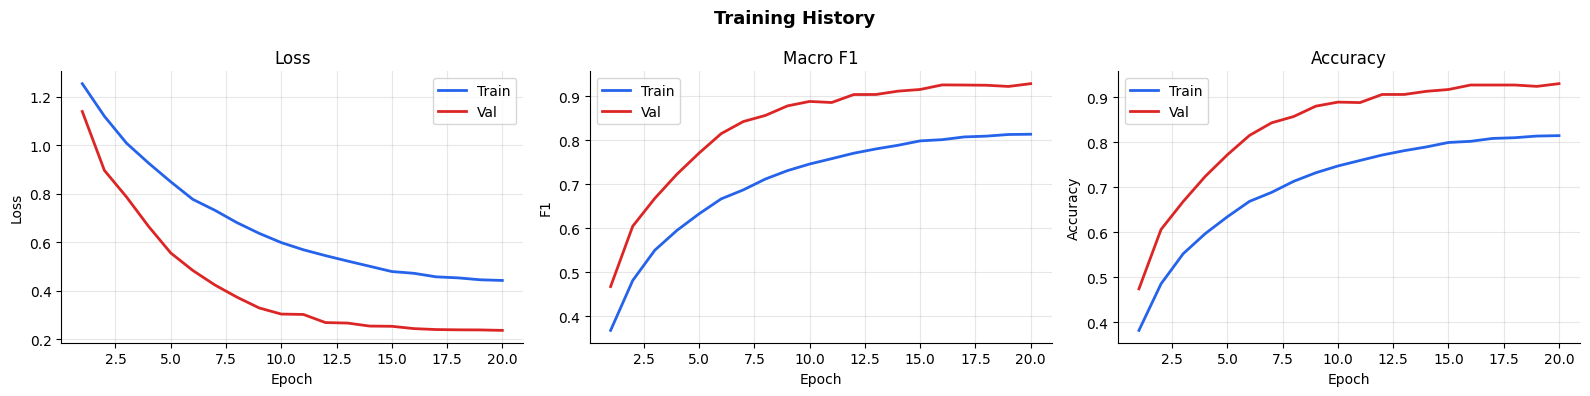

Saved: outputs/training_curves.png


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Training History", fontsize=13, fontweight="bold")
ep = range(1, len(history["train_loss"])+1)
for ax, (trk, vak, title, ylabel) in zip(axes, [
    ("train_loss","val_loss","Loss","Loss"),
    ("train_f1","val_f1","Macro F1","F1"),
    ("train_acc","val_acc","Accuracy","Accuracy")]):
    ax.plot(ep, history[trk], label="Train", color="#2563eb", linewidth=2)
    ax.plot(ep, history[vak], label="Val",   color="#dc2626", linewidth=2)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/training_curves.png")

## Cell 12 — Confusion matrix & classification report

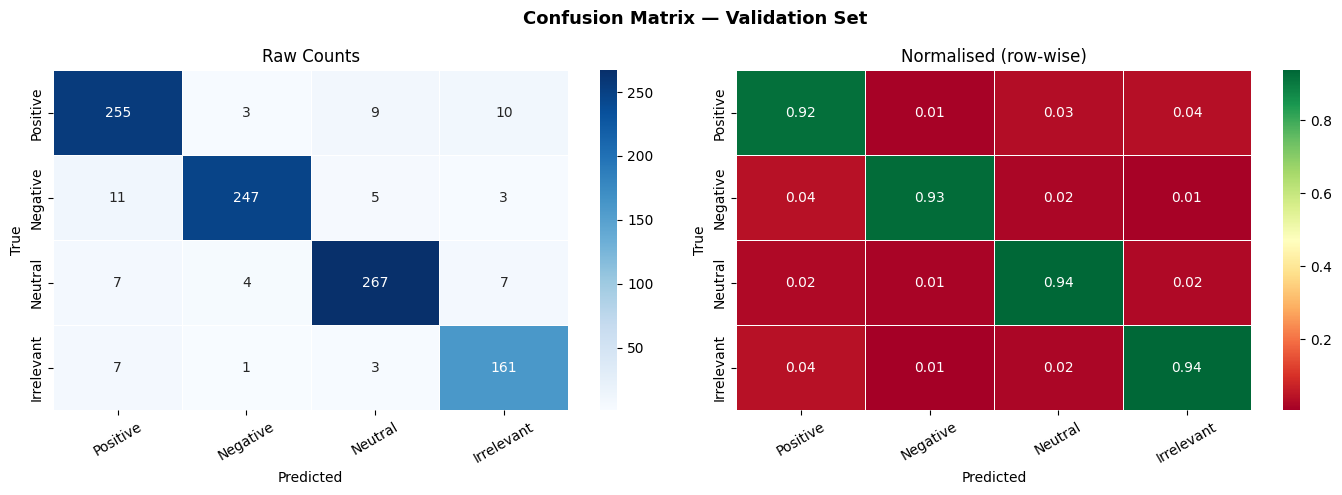

VALIDATION SET — DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Positive     0.9107    0.9206    0.9156       277
    Negative     0.9686    0.9286    0.9482       266
     Neutral     0.9401    0.9368    0.9385       285
  Irrelevant     0.8895    0.9360    0.9122       172

    accuracy                         0.9300      1000
   macro avg     0.9272    0.9305    0.9286      1000
weighted avg     0.9309    0.9300    0.9302      1000

Balanced accuracy : 0.9305

Sanity check — hand-rolled vs sklearn:
  macro F1 : custom=0.9286  sklearn=0.9286  OK
  accuracy : custom=0.9300  sklearn=0.9300  OK

MODEL COMPARISON
  Model                              Acc      F1
  ------------------------------ ------- -------
  TF-IDF + LogReg (baseline)      0.9550  0.9536
  BiLSTM + Attention (val)        0.9300  0.9286


In [11]:
import seaborn as sns
import numpy as np
from sklearn.metrics import (classification_report, balanced_accuracy_score,
                              f1_score, accuracy_score)

ckpt = torch.load("outputs/best_model.pt", map_location=device)
model.load_state_dict(ckpt["state_dict"])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for tokens, labels in val_loader:
        all_preds.extend(model(tokens.to(device)).argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())

cm = np.zeros((4,4), dtype=int)
for t, p in zip(all_labels, all_preds): cm[t][p] += 1
cm_norm = cm.astype(float)
for i in range(4):
    if cm[i].sum() > 0: cm_norm[i] /= cm[i].sum()

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle("Confusion Matrix — Validation Set", fontsize=13, fontweight="bold")
sns.heatmap(cm,      annot=True, fmt="d",    cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5, linecolor="white")
axes[0].set_title("Raw Counts"); axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")
axes[0].tick_params(axis="x", rotation=30)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="RdYlGn",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, linecolor="white")
axes[1].set_title("Normalised (row-wise)"); axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("=" * 60)
print("VALIDATION SET — DETAILED CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))
print(f"Balanced accuracy : {balanced_accuracy_score(all_labels, all_preds):.4f}")

sk_f1  = f1_score(all_labels, all_preds, average="macro")
sk_acc = accuracy_score(all_labels, all_preds)
custom = compute_metrics(all_preds, all_labels)
print("\nSanity check — hand-rolled vs sklearn:")
print(f"  macro F1 : custom={custom['macro_f1']:.4f}  sklearn={sk_f1:.4f}"
      f"  {'OK' if abs(custom['macro_f1']-sk_f1)<1e-3 else 'MISMATCH'}")
print(f"  accuracy : custom={custom['accuracy']:.4f}  sklearn={sk_acc:.4f}"
      f"  {'OK' if abs(custom['accuracy']-sk_acc)<1e-3 else 'MISMATCH'}")

if "BASELINE_RESULTS" in globals():
    print("\n" + "="*45)
    print("MODEL COMPARISON")
    print("="*45)
    print(f"  {'Model':<30} {'Acc':>7} {'F1':>7}")
    print(f"  {'-'*30} {'-'*7} {'-'*7}")
    print(f"  {BASELINE_RESULTS['model']:<30} {BASELINE_RESULTS['val_acc']:>7.4f} {BASELINE_RESULTS['macro_f1']:>7.4f}")
    print(f"  {'BiLSTM + Attention (val)':<30} {sk_acc:>7.4f} {sk_f1:>7.4f}")

## Cell 13 — Final evaluation on held-out test set

Run this only once, after all training and tuning is complete.

In [12]:
from sklearn.metrics import classification_report, f1_score, accuracy_score

model.eval()
test_preds, test_labels_list = [], []
with torch.no_grad():
    for tokens, labels in test_loader:
        test_preds.extend(model(tokens.to(device)).argmax(1).cpu().tolist())
        test_labels_list.extend(labels.tolist())

print("=" * 60)
print("HELD-OUT TEST SET — FINAL RESULTS")
print("=" * 60)
print(classification_report(test_labels_list, test_preds,
                             target_names=CLASS_NAMES, digits=4))
print(f"Test macro F1 : {f1_score(test_labels_list, test_preds, average='macro'):.4f}")
print(f"Test accuracy : {accuracy_score(test_labels_list, test_preds):.4f}")

HELD-OUT TEST SET — FINAL RESULTS
              precision    recall  f1-score   support

    Positive     0.8447    0.8292    0.8369      2079
    Negative     0.9065    0.8098    0.8554      2250
     Neutral     0.8902    0.7990    0.8421      1826
  Irrelevant     0.6951    0.9444    0.8008      1296

    accuracy                         0.8360      7451
   macro avg     0.8341    0.8456    0.8338      7451
weighted avg     0.8485    0.8360    0.8375      7451

Test macro F1 : 0.8338
Test accuracy : 0.8360


## Cell 14 — Interactive prediction widget

In [13]:
import ipywidgets as widgets
import torch.nn.functional as F
from IPython.display import display, HTML, clear_output

COLORS = {"Positive":"#22c55e","Negative":"#ef4444",
          "Neutral":"#64748b","Irrelevant":"#a855f7"}

def predict(text):
    cleaned = clean_tweet(text)
    enc     = vocab.encode(cleaned)[:MAX_LEN]
    if not enc: enc = [UNK_IDX]
    enc += [0] * (MAX_LEN - len(enc))
    ids = torch.tensor([enc], dtype=torch.long, device=device)
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(ids), dim=-1)[0]
    idx = probs.argmax().item()
    return {"label":ID2LABEL[idx],
            "confidence":f"{probs[idx].item():.1%}",
            "probabilities":{ID2LABEL[i]:f"{probs[i].item():.1%}" for i in range(4)}}

text_box = widgets.Textarea(placeholder="Type any tweet here...",
                             layout=widgets.Layout(width="580px", height="80px"))
btn    = widgets.Button(description="Predict", button_style="primary",
                        layout=widgets.Layout(width="110px"))
output = widgets.Output()

def on_click(_):
    with output:
        clear_output(wait=True)
        txt = text_box.value.strip()
        if not txt: print("Please enter some text first."); return
        r = predict(txt); label = r["label"]; color = COLORS[label]
        rows = ""
        for lbl, prob_str in r["probabilities"].items():
            pct = float(prob_str.rstrip("%")); w = int(pct*1.8); c = COLORS[lbl]
            bold = "font-weight:bold;" if lbl == label else ""
            rows += (f"<div style='margin:3px 0;{bold}'>"
                     f"<span style='display:inline-block;width:85px'>{lbl}</span>"
                     f"<span style='display:inline-block;width:{w}px;background:{c};"
                     f"height:14px;border-radius:3px;margin-right:6px'></span>"
                     f"{prob_str}</div>")
        display(HTML(
            f"<div style='font-family:sans-serif;padding:12px;border-radius:8px;"
            f"border:2px solid {color};max-width:520px;margin-top:8px'>"
            f"<div style='font-size:1.2em;font-weight:bold;color:{color}'>"
            f"{label} &nbsp;({r['confidence']})</div>"
            f"<div style='font-size:0.82em;color:#666;margin:5px 0'>"
            f"Cleaned: <i>{clean_tweet(txt)}</i></div>"
            f"<hr style='margin:7px 0;border:none;border-top:1px solid #e5e7eb'>"
            f"{rows}</div>"))

btn.on_click(on_click)
display(widgets.VBox([text_box, btn, output]))

## Cell 15 — Write deployment files

In [14]:
import os

os.makedirs("outputs", exist_ok=True)

# ── Gradio app ───────────────────────────────────────────────────────────────
gradio_lines = [
    "import gradio as gr, torch, json, re\n",
    "import torch.nn.functional as F\n",
    "\n",
    "PAD_IDX, UNK_IDX = 0, 1\n",
    "LABEL_MAP = {\"Positive\":0,\"Negative\":1,\"Neutral\":2,\"Irrelevant\":3}\n",
    "ID2LABEL  = {v:k for k,v in LABEL_MAP.items()}\n",
    "CLASS_NAMES = list(LABEL_MAP.keys())\n",
    "MAX_LEN = 100\n",
    "\n",
    "# Paste your clean_tweet() and LSTMSentimentClassifier here\n",
    "# or import them from a separate model.py\n",
    "\n",
    "device = torch.device(\"cuda\" if torch.cuda.is_available() else \"cpu\")\n",
    "with open(\"outputs/vocab.json\") as f: vocab_data = json.load(f)\n",
    "word2idx = vocab_data[\"word2idx\"]; vocab_size = vocab_data[\"vocab_size\"]\n",
    "from model import LSTMSentimentClassifier\n",
    "ckpt  = torch.load(\"outputs/best_model.pt\", map_location=device)\n",
    "model = LSTMSentimentClassifier(vocab_size=vocab_size,\n",
    "    embed_dim=ckpt.get(\"embed_dim\",128), hidden_dim=ckpt.get(\"hidden_dim\",256),\n",
    "    num_layers=ckpt.get(\"num_layers\",2), num_classes=4, dropout=0.0, pad_idx=PAD_IDX).to(device)\n",
    "model.load_state_dict(ckpt[\"state_dict\"]); model.eval()\n",
    "\n",
    "def predict_sentiment(text):\n",
    "    enc = [word2idx.get(w, UNK_IDX) for w in text.lower().split()][:MAX_LEN]\n",
    "    enc += [PAD_IDX] * (MAX_LEN - len(enc))\n",
    "    ids = torch.tensor([enc], dtype=torch.long, device=device)\n",
    "    with torch.no_grad(): probs = F.softmax(model(ids),dim=-1)[0].cpu().tolist()\n",
    "    return {CLASS_NAMES[i]: round(probs[i],4) for i in range(4)}\n",
    "\n",
    "demo = gr.Interface(fn=predict_sentiment,\n",
    "    inputs=gr.Textbox(label=\"Tweet\", lines=3),\n",
    "    outputs=gr.Label(num_top_classes=4),\n",
    "    title=\"Twitter Sentiment Analyser\",\n",
    "    theme=gr.themes.Soft())\n",
    "\n",
    "if __name__ == \"__main__\": demo.launch(share=True)\n"
]
with open("outputs/gradio_app.py","w") as f: f.writelines(gradio_lines)

# ── FastAPI app ───────────────────────────────────────────────────────────────
fastapi_lines = [
    "# Install: pip install fastapi uvicorn torch\n",
    "# Run:     uvicorn fastapi_app:app --host 0.0.0.0 --port 8000\n",
    "from fastapi import FastAPI, HTTPException\n",
    "from pydantic import BaseModel, Field\n",
    "from typing import Dict\n",
    "import torch, json, time\n",
    "import torch.nn.functional as F\n",
    "\n",
    "PAD_IDX, UNK_IDX = 0, 1\n",
    "LABEL_MAP = {\"Positive\":0,\"Negative\":1,\"Neutral\":2,\"Irrelevant\":3}\n",
    "ID2LABEL  = {v:k for k,v in LABEL_MAP.items()}\n",
    "MAX_LEN   = 100\n",
    "\n",
    "# Paste clean_tweet() and LSTMSentimentClassifier here or import from model.py\n",
    "\n",
    "device = torch.device(\"cuda\" if torch.cuda.is_available() else \"cpu\")\n",
    "with open(\"outputs/vocab.json\") as f: vocab_data = json.load(f)\n",
    "word2idx = vocab_data[\"word2idx\"]; vocab_size = vocab_data[\"vocab_size\"]\n",
    "from model import LSTMSentimentClassifier\n",
    "ckpt  = torch.load(\"outputs/best_model.pt\", map_location=device)\n",
    "model = LSTMSentimentClassifier(vocab_size=vocab_size,\n",
    "    embed_dim=ckpt.get(\"embed_dim\",128), num_classes=4,\n",
    "    dropout=0.0, pad_idx=PAD_IDX).to(device)\n",
    "model.load_state_dict(ckpt[\"state_dict\"]); model.eval()\n",
    "\n",
    "app = FastAPI(title=\"Twitter Sentiment API\", version=\"1.0.0\")\n",
    "\n",
    "class PredictRequest(BaseModel):\n",
    "    text: str = Field(..., min_length=1)\n",
    "\n",
    "@app.get(\"/health\")\n",
    "def health(): return {\"status\":\"ok\"}\n",
    "\n",
    "@app.post(\"/predict\")\n",
    "def predict(req: PredictRequest):\n",
    "    t0  = time.perf_counter()\n",
    "    enc = [word2idx.get(w,UNK_IDX) for w in req.text.lower().split()][:MAX_LEN]\n",
    "    enc += [PAD_IDX]*(MAX_LEN-len(enc))\n",
    "    ids = torch.tensor([enc],dtype=torch.long,device=device)\n",
    "    with torch.no_grad(): probs=F.softmax(model(ids),dim=-1)[0].cpu().tolist()\n",
    "    idx = int(max(range(4),key=lambda i:probs[i]))\n",
    "    return {\"label\":ID2LABEL[idx],\"confidence\":round(probs[idx],4),\n",
    "            \"probabilities\":{ID2LABEL[i]:round(probs[i],4) for i in range(4)},\n",
    "            \"latency_ms\":round((time.perf_counter()-t0)*1000,2)}\n"
]
with open("outputs/fastapi_app.py","w") as f: f.writelines(fastapi_lines)

# ── Dockerfile ───────────────────────────────────────────────────────────────
dockerfile_lines = [
    "FROM python:3.11-slim\n",
    "WORKDIR /app\n",
    "RUN pip install --no-cache-dir fastapi uvicorn[standard] torch "
    "--index-url https://download.pytorch.org/whl/cpu\n",
    "COPY outputs/ outputs/\n",
    "COPY model.py .\n",
    "COPY fastapi_app.py .\n",
    "EXPOSE 8000\n",
    "CMD [\"uvicorn\",\"fastapi_app:app\",\"--host\",\"0.0.0.0\",\"--port\",\"8000\"]\n"
]
with open("outputs/Dockerfile","w") as f: f.writelines(dockerfile_lines)

print("Deployment files written to outputs/:")
for fn in ["gradio_app.py","fastapi_app.py","Dockerfile"]:
    print(f"  {fn}  ({os.path.getsize(f'outputs/{fn}')/1024:.1f} KB)")

Deployment files written to outputs/:
  gradio_app.py  (1.5 KB)
  fastapi_app.py  (1.8 KB)
  Dockerfile  (0.3 KB)


## Cell 16 — Download all artifacts

In [15]:
import zipfile, os
from google.colab import files

artifacts = [
    "outputs/best_model.pt",
    "outputs/vocab.json",
    "outputs/config.json",
    "outputs/history.json",
    "outputs/training_curves.png",
    "outputs/confusion_matrix.png",
    "outputs/gradio_app.py",
    "outputs/fastapi_app.py",
    "outputs/Dockerfile",
]

with zipfile.ZipFile("model_artifacts.zip","w",zipfile.ZIP_DEFLATED) as zf:
    for path in artifacts:
        if os.path.exists(path):
            zf.write(path); print(f"  added   : {path}")
        else:
            print(f"  MISSING : {path}")

mb = os.path.getsize("model_artifacts.zip") / 1024 / 1024
print(f"\nmodel_artifacts.zip  ({mb:.1f} MB)")
files.download("model_artifacts.zip")

  added   : outputs/best_model.pt
  added   : outputs/vocab.json
  added   : outputs/config.json
  added   : outputs/history.json
  added   : outputs/training_curves.png
  added   : outputs/confusion_matrix.png
  added   : outputs/gradio_app.py
  added   : outputs/fastapi_app.py
  added   : outputs/Dockerfile

model_artifacts.zip  (18.2 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>